
# Personalizing Temporal Stabilization Dosage with CATE Estimation

**A practical project based on *Causal Inference in Python*, Chapter 6 — "Effect Heterogeneity"**

*(Yes, the time-travel industry. The causal-inference math doesn't care what year it is.)*

## The business problem

You're the lead data scientist at **ChronoDynamics Corp.**, a commercial time-travel
operator. Every jump into the past subjects a traveler to **temporal strain** — the further
back you go, the more your body and mind resist re-anchoring to a timeline that isn't
"yours." Left unmanaged, high strain causes mission failure: disorientation, memory
smearing, and in bad cases, the traveler snapping back mid-mission.

ChronoDynamics sells **Chronostabilization Serum**, an injectable dosed in milligrams before
departure that counteracts strain. It's not free, though — like any pharmacological
intervention, higher doses carry a **side-effect risk** (nausea, temporal nosebleeds, the
occasional bout of speaking in Middle English), so you can't just max out every traveler's
dose "to be safe."

The company ran a **randomized pilot**: a random serum dose (0–50 mg) was assigned to
travelers before their jump, and mission control measured each traveler's **coherence
score** — a 0–100 measure of how successfully they stayed anchored and completed the
mission.

A single **average** effect ("1 mg of serum buys X points of coherence, on average") tells
you whether the serum is worth manufacturing at all. But it hides something important:
**some travelers respond to the serum far more than others.** A first-time tourist hopping
back 10 years barely needs it; a seasoned operative jumping back 900 years into a
pre-modern era, with a low natural chronotolerance, needs a lot more help per mg — or
maybe the serum barely works for them at all and a different intervention is needed. Dosing
everyone the same wastes serum on low-responders and under-protects high-responders.

This is exactly the CATE (conditional average treatment effect) problem from the chapter,
transplanted from restaurant discounts and %-off coupons into milligrams and centuries:

- **ATE** — `E[Y1 - Y0]`: is the serum worth stocking on every mission at all?
- **CATE** — `E[Y1 - Y0 | X]`: *which travelers* need serum, and *how many mg* should each
  one get, given that higher doses cost more (in dollars *and* side-effect risk)?

In this notebook we will, step by step:

1. Simulate a realistic Chronostabilization pilot dataset (with a **known ground-truth
   CATE**, so we can grade ourselves — impossible with real data, since the individual
   treatment effect is fundamentally unobservable, temporal paradoxes or not).
2. Show why a plain coherence-prediction model is not the same as a dose-sensitivity model.
3. Estimate the **ATE** — the average mg-to-coherence conversion rate.
4. Estimate the **CATE** with linear regression + treatment-covariate interactions.
5. Benchmark the CATE model against a purely predictive ML model and a random model.
6. Evaluate CATE quality with the tools from the chapter:
   - Effect by model quantile
   - Cumulative effect curve
   - Cumulative gain curve (+ normalized) and its AUC
   - Target transformation + weighted MSE
7. **Use** the CATE model for the decision that actually matters: solve for the
   **profit/value-maximizing serum dose per traveler**, trading off mission value against
   serum cost and side-effect risk — and compare personalized dosing to a flat,
   one-dose-for-everyone policy.

Every section explains the *why*, not just the *how*, so you walk away understanding the
reasoning, not just the code.



## 1. Setup


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from toolz import curry

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## 2. Simulate the Chronostabilization pilot

One row per **traveler-mission**: a traveler observed on one jump. We simulate a pilot with
the same logical structure as the book's restaurant example, but for time travel:

- `serum_dose_mg` (the treatment) is a **randomized** dose, 0–50 mg, assigned before
  departure — so there's no confounding, and we can focus purely on estimation and
  evaluation, exactly as the chapter does.
- The **true sensitivity** to serum (coherence points gained per mg) depends on:
  - `jump_distance_years` — deeper jumps into the past create more strain, and serum has
    *more* room to help (up to a point).
  - `traveler_age` — younger travelers' neuro-anchoring is more pliable and responds better.
  - `prior_jumps` — experienced travelers have partially adapted physiology and get less
    marginal benefit per mg (they're already somewhat "trained").
  - `chronotolerance_gene` — a subset of the population (rare genetic marker) barely needs
    serum at all; their bodies self-stabilize.
  - `era_turbulence` — some historical eras (wartime, plagues, etc.) have more "timeline
    noise," which increases strain and makes serum more necessary.
- `coherence_score` (the outcome) is generated from baseline coherence plus
  `tau(X) * serum_dose_mg` plus noise.


In [2]:

n_travelers = 5000

data = pd.DataFrame({
    "traveler_id": np.arange(n_travelers),
    "jump_distance_years": np.random.gamma(shape=2.2, scale=90, size=n_travelers).clip(1, 1000),
    "traveler_age": np.random.uniform(19, 70, n_travelers),
    "prior_jumps": np.random.poisson(3, n_travelers),
    "chronotolerance_gene": np.random.binomial(1, 0.12, n_travelers),  # rare "natural" trait
})

# Era turbulence: eras far in the past AND historically chaotic periods have more noise.
# We model it as increasing with distance, plus a chance of hitting a "volatile window".
volatile_window = np.random.binomial(1, 0.20, n_travelers)
data["era_turbulence"] = (
    0.015 * data["jump_distance_years"] + 8 * volatile_window
    + np.random.normal(0, 3, n_travelers)
).clip(lower=0)

# --- Randomized treatment: serum dose in mg, 0 to 50 ---
data["serum_dose_mg"] = np.random.uniform(0, 50, n_travelers)

# --- Ground-truth CATE function tau(X): coherence points gained per mg of serum ---
data["true_tau"] = (
    0.35
    + 0.006 * data["jump_distance_years"]
    - 0.012 * data["traveler_age"]
    - 0.05 * data["prior_jumps"]
    - 1.1 * data["chronotolerance_gene"]       # genetically tolerant travelers need little help
    + 0.03 * data["era_turbulence"]
).clip(lower=0.0)

# --- Outcome model: baseline coherence - strain + treatment effect + noise ---
baseline_strain = 0.05 * data["jump_distance_years"] + 0.6 * data["era_turbulence"]
data["coherence_score"] = (
    95
    - baseline_strain
    - 0.15 * data["prior_jumps"]
    + 3.0 * data["chronotolerance_gene"]
    + data["true_tau"] * data["serum_dose_mg"]
    + np.random.normal(0, 6, n_travelers)
).clip(0, 100)

print(data.shape)
data.head()


(5000, 9)


,traveler_id,jump_distance_years,traveler_age,prior_jumps,chronotolerance_gene,era_turbulence,serum_dose_mg,true_tau,coherence_score
0,0,236.778410,69.926573,3,0,4.560758,3.401526,0.918374,74.460358
1,1,151.565612,41.086881,1,0,11.372307,0.146583,1.057520,69.105094
2,2,140.821215,54.851249,4,1,1.977211,38.342895,0.000000,83.464779
3,3,140.823010,28.315815,6,0,0.000000,14.502694,0.555148,99.859644
4,4,446.611545,50.103305,0,0,7.288697,44.360261,2.647091,100.000000



## 3. Why prediction is not the answer

Before touching CATE, let's confirm the chapter's core warning in this new setting:
**grouping travelers by predicted coherence (`Y`) is not the same as grouping them by serum
sensitivity (`dY/d(mg)`)**. A traveler with a *low* predicted coherence score might be
low-coherence because they're jumping somewhere brutal (high sensitivity to serum — it can
really help) or because they have a rare condition serum barely touches (low sensitivity).
Predicted `Y` alone can't tell those two cases apart.


Correlation between raw coherence score and true serum sensitivity: 0.189


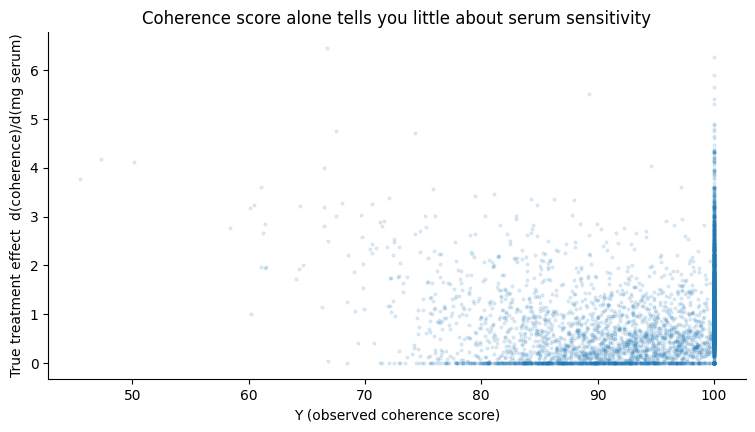

In [3]:

corr = data[["coherence_score", "true_tau"]].corr().iloc[0, 1]
print(f"Correlation between raw coherence score and true serum sensitivity: {corr:.3f}")

fig, ax = plt.subplots()
ax.scatter(data["coherence_score"], data["true_tau"], s=4, alpha=0.12)
ax.set_xlabel("Y (observed coherence score)")
ax.set_ylabel("True treatment effect  d(coherence)/d(mg serum)")
ax.set_title("Coherence score alone tells you little about serum sensitivity")
plt.show()



Exactly as in the book: outcome level and true treatment sensitivity are, in general,
different things. A model that predicts `coherence_score` well is **not automatically** a
model that tells mission control who needs more serum.

## 4. The ATE: is Chronostabilization Serum worth stocking?

Since `serum_dose_mg` was randomized, the chapter's simple regression-slope estimator
recovers the ATE without bias — this answers the **program evaluation** question: on
average, is a milligram of serum worth its manufacturing cost?


In [4]:

@curry
def effect(data, y, t):
    # Simple regression-slope estimator of the effect of t on y (chapter's `effect` fn).
    return (
        np.sum((data[t] - data[t].mean()) * (data[y] - data[y].mean()))
        / np.sum((data[t] - data[t].mean()) ** 2)
    )

ate = effect(data, "coherence_score", "serum_dose_mg")
print(f"Estimated ATE (coherence points gained per mg): {ate:.4f}")
print(f"True average tau in the population:             {data['true_tau'].mean():.4f}")


Estimated ATE (coherence points gained per mg): 0.2593
True average tau in the population:             0.9355



That average number justifies stocking the serum at all. But it tells every traveler to
expect the *same* mg-to-coherence conversion — which we already know from `true_tau` is
false. Genetically tolerant travelers barely need it; travelers jumping into turbulent,
distant eras need a lot more per mg to stay anchored. That's the personalization gap CATE
closes.

## 5. Estimating the CATE with regression + interactions

Following the chapter, we fit

```
coherence_i = b0 + b1*dose_i + b2*X_i*dose_i + b3*X_i + e_i
```

and differentiate with respect to `serum_dose_mg` to get a *predicted* slope `b1 + b2*X_i`
that varies by traveler and mission characteristics — a CATE model — even though the true
per-traveler slope is never directly observed.

Covariates: `jump_distance_years`, `traveler_age`, `prior_jumps`, `chronotolerance_gene`,
`era_turbulence` — everything mission planning would know before departure.


In [5]:

X = ["jump_distance_years", "traveler_age", "prior_jumps",
     "chronotolerance_gene", "era_turbulence"]
formula = f"coherence_score ~ serum_dose_mg*({'+'.join(X)})"
regr_cate = smf.ols(formula, data=data).fit()

# Predicted slope via finite differences (exact for a linear model; the same trick
# generalizes to any model class).
cate_pred_full = (
    regr_cate.predict(data.assign(serum_dose_mg=data["serum_dose_mg"] + 1))
    - regr_cate.predict(data)
)

print("Correlation between CATE prediction and ground truth (full data, in-sample):",
      round(np.corrcoef(cate_pred_full, data["true_tau"])[0, 1], 3))


Correlation between CATE prediction and ground truth (full data, in-sample): 0.929



## 6. Honest evaluation: train/test split

We split by traveler into a random 70/30 train/test partition (there's no natural time axis
here the way there was for the restaurant's calendar days — a fresh random split serves the
same purpose: making sure every downstream evaluation is out-of-sample).


In [6]:

rng = np.random.default_rng(7)
idx = rng.permutation(data.index)
n_train = int(0.7 * len(data))
train = data.loc[idx[:n_train]]
test = data.loc[idx[n_train:]]

regr_model = smf.ols(formula, data=train).fit()

cate_pred = (
    regr_model.predict(test.assign(serum_dose_mg=test["serum_dose_mg"] + 1))
    - regr_model.predict(test)
)

print(f"Train rows: {len(train):,}   Test rows: {len(test):,}")


Train rows: 3,500   Test rows: 1,500



## 7. Two benchmarks

As in the chapter, we compare our CATE model against:

- **A purely predictive ML model** (`GradientBoostingRegressor` predicting
  `coherence_score` directly, *not* the effect). This is the natural instinct — and the
  whole point of the chapter is that it's the wrong tool for dosing decisions.
- **A random model** that outputs noise. If our CATE model can't beat this, mission control
  shouldn't trust it with anyone's timeline.


In [7]:

np.random.seed(1)
X_ml = ["jump_distance_years", "traveler_age", "prior_jumps",
        "chronotolerance_gene", "era_turbulence", "serum_dose_mg"]
ml_model = GradientBoostingRegressor(n_estimators=400, random_state=1)
ml_model.fit(train[X_ml], train["coherence_score"])
ml_pred = ml_model.predict(test[X_ml])

np.random.seed(123)
rand_pred = np.random.uniform(-1, 1, len(test))

test_pred = test.assign(
    ml_pred=ml_pred,
    cate_pred=cate_pred,
    rand_m_pred=rand_pred,
)
test_pred[["coherence_score", "serum_dose_mg", "true_tau",
           "ml_pred", "cate_pred", "rand_m_pred"]].head()


,coherence_score,serum_dose_mg,true_tau,ml_pred,cate_pred,rand_m_pred
3843,96.825235,30.558557,0.000000,88.538668,0.102378,0.392938
1412,100.000000,17.337652,2.145668,99.038426,0.529315,-0.427721
4564,85.472526,13.793471,0.850921,94.096223,0.214324,-0.546297
2063,100.000000,21.271666,1.841316,99.648939,0.345074,0.102630
436,100.000000,29.434333,0.926876,98.785685,0.256475,0.438938



## 8. Evaluation tool #1 — Effect by model quantile

Since the individual treatment effect is unobservable, we bucket traveler-missions into
quantiles of each model's prediction, and estimate the **group-level** effect (via the same
regression-slope estimator used for the ATE) inside each bucket. A good CATE model produces
a monotonically increasing "staircase."


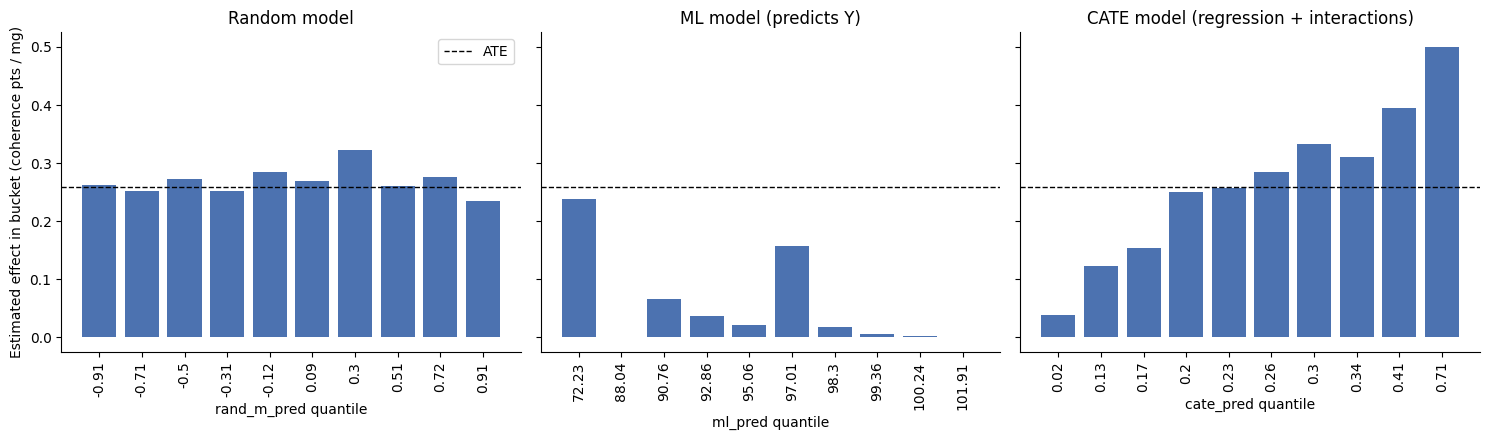

In [8]:

def effect_by_quantile(df, pred, y="coherence_score", t="serum_dose_mg", q=10):
    groups = np.round(pd.IntervalIndex(pd.qcut(df[pred], q=q, duplicates="drop")).mid, 2)
    return (
        df.assign(**{f"{pred}_quantile": groups})
          .groupby(f"{pred}_quantile", observed=True)
          .apply(effect(y=y, t=t), include_groups=False)
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, col, title in zip(
    axes,
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["Random model", "ML model (predicts Y)", "CATE model (regression + interactions)"],
):
    eq = effect_by_quantile(test_pred, col)
    ax.bar(range(len(eq)), eq.values, color="#4C72B0")
    ax.axhline(ate, color="black", linestyle="--", linewidth=1, label="ATE")
    ax.set_xticks(range(len(eq)))
    ax.set_xticklabels(eq.index, rotation=90)
    ax.set_title(title)
    ax.set_xlabel(f"{col} quantile")
axes[0].set_ylabel("Estimated effect in bucket (coherence pts / mg)")
axes[0].legend()
plt.tight_layout()
plt.show()



Same interpretation as the chapter: the random model hovers flat around the ATE — useless
for dosing decisions. The ML model may show *some* structure, but no reliable ordering. The
CATE model should show a clean staircase — proof it separates high- and low-responding
travelers.

## 9. Evaluation tool #2 — Cumulative effect curve

Sort traveler-missions by the model's prediction and **accumulate**: estimate the effect on
the top 1% most-serum-sensitive travelers, then top 2%, ..., up to 100%. A good model starts
high and decays smoothly to the ATE.


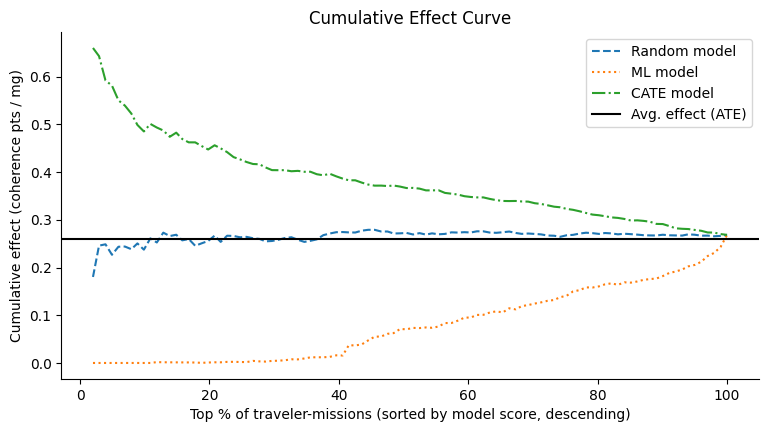

In [9]:

def cumulative_effect_curve(dataset, prediction, y="coherence_score", t="serum_dose_mg",
                             min_rows=30, steps=100):
    size = len(dataset)
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = np.linspace(min_rows, size, steps).astype(int)
    return np.array([effect(ordered_df.head(rows), y, t) for rows in n_rows]), n_rows

fig, ax = plt.subplots()
for col, style, label in zip(
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["--", ":", "-."],
    ["Random model", "ML model", "CATE model"],
):
    curve, n_rows = cumulative_effect_curve(test_pred, col)
    ax.plot(100 * n_rows / len(test_pred), curve, style, label=label)

ax.axhline(ate, color="black", linewidth=1.5, label="Avg. effect (ATE)")
ax.set_xlabel("Top % of traveler-missions (sorted by model score, descending)")
ax.set_ylabel("Cumulative effect (coherence pts / mg)")
ax.set_title("Cumulative Effect Curve")
ax.legend()
plt.show()



## 10. Evaluation tool #3 — Cumulative gain curve (+ normalized) and AUC

The cumulative effect curve over-weights its earliest (noisiest, smallest-sample) points.
The chapter's fix: multiply each point by the cumulative sample fraction `N_cum/N` to get
the **cumulative gain curve**, then normalize and reduce it to a single AUC number for
automated model comparison.


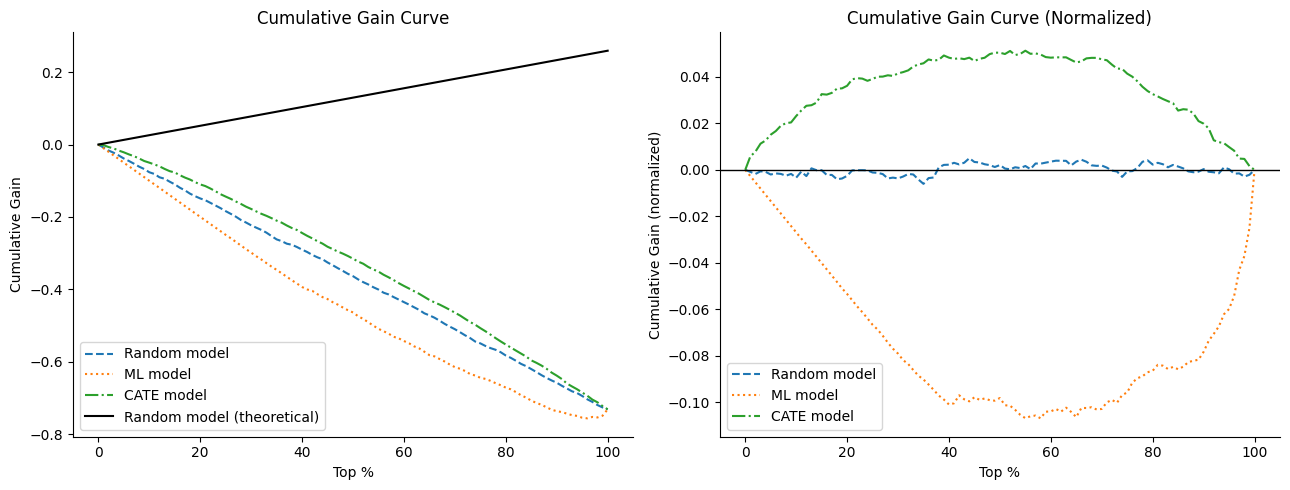

AUC for rand_m_pred: 0.01
AUC for ml_pred: -7.48
AUC for cate_pred: 3.53


In [10]:

def cumulative_gain_curve(df, prediction, y="coherence_score", t="serum_dose_mg",
                           steps=100, normalize=True):
    effect_fn = effect(y=y, t=t)
    normalizer = effect_fn(df) if normalize else 1.0
    size = len(df)
    ordered_df = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = np.linspace(size / steps, size, steps).astype(int)
    gains = [
        (effect_fn(ordered_df.head(rows)) - normalizer) * (rows / size)
        for rows in n_rows
    ]
    return np.array([0] + gains), np.array([0] + list(100 * n_rows / size))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
aucs = {}
for col, style, label in zip(
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["--", ":", "-."],
    ["Random model", "ML model", "CATE model"],
):
    gain, pct = cumulative_gain_curve(test_pred, col, normalize=False)
    gain_n, _ = cumulative_gain_curve(test_pred, col, normalize=True)
    axes[0].plot(pct, gain, style, label=label)
    axes[1].plot(pct, gain_n, style, label=label)
    aucs[col] = gain_n.sum()

axes[0].plot([0, 100], [0, ate], color="black", label="Random model (theoretical)")
axes[0].set_title("Cumulative Gain Curve")
axes[0].set_xlabel("Top %"); axes[0].set_ylabel("Cumulative Gain"); axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Cumulative Gain Curve (Normalized)")
axes[1].set_xlabel("Top %"); axes[1].set_ylabel("Cumulative Gain (normalized)"); axes[1].legend()
plt.tight_layout()
plt.show()

for k, v in aucs.items():
    print(f"AUC for {k}: {v:.2f}")



The bigger the area between the normalized curve and zero, the better the model orders true
CATE. We'd expect `cate_pred` to dominate, `rand_m_pred` to hover near zero, and `ml_pred`
to land somewhere weaker in between.

## 11. Evaluation tool #4 — Target transformation + weighted MSE

The curves above only check **ordering**, not calibration. To probe calibration, we build
the chapter's approximate individual-level target:

```
Y*_i = (Y_i - mu_y(X_i)) / (T_i - mu_t(X_i))
```

which satisfies `E[Y*_i] = tau_i` in expectation, even though we can't observe `tau_i`
directly. We weight by `(T_i - mu_t(X_i))^2` to downweight the noisiest points (where the
denominator is near zero), then compute a weighted MSE against `Y*` for each model.


In [11]:

X_form = "+".join(X)
y_res = smf.ols(f"coherence_score ~ {X_form}", data=test).fit().resid
t_res = smf.ols(f"serum_dose_mg ~ {X_form}", data=test).fit().resid
tau_hat = y_res / t_res
weights = t_res ** 2

for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    wmse = mean_squared_error(tau_hat, test_pred[m], sample_weight=weights)
    print(f"Weighted MSE for {m}: {wmse:,.3f}")

# Because we simulated the data, we can go one step further than the book and also check
# calibration against the TRUE tau directly:
print("\n--- Only possible because this is simulated data ---")
for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    corr = np.corrcoef(test_pred[m], test_pred["true_tau"])[0, 1]
    print(f"Correlation of {m} with true_tau: {corr:.3f}")


Weighted MSE for rand_m_pred: 0.572
Weighted MSE for ml_pred: 8,503.255
Weighted MSE for cate_pred: 0.137

--- Only possible because this is simulated data ---
Correlation of rand_m_pred with true_tau: 0.010
Correlation of ml_pred with true_tau: 0.188
Correlation of cate_pred with true_tau: 0.917



## 12. From CATE to a decision: profit-maximizing serum dosing

This is the payoff. Knowing *who* is more or less serum-sensitive is only useful if it
changes a decision. Following the chapter's price-optimization walkthrough, suppose
ChronoDynamics values each mission at a fixed **mission value** `V` (ticket revenue +
reputational value of a clean timeline), realized in proportion to how coherent the
traveler stays, and faces a **convex cost of dosing** (side-effect risk grows faster than
linearly with dose):

- `MissionValue_i = V * min(1, coherence_i / 100)` — a cleaner anchor makes the mission
  more likely to fully succeed. We'll linearize this locally around the treatment effect,
  same idea as the book's `Demand = 50 - tau(X)*Price` simplification.
- `Cost_i(dose) = c1 * dose_i + c2 * dose_i^2` — serum itself has a flat per-mg cost `c1`,
  plus a convex side-effect risk cost `c2 * dose^2` (double the dose, quadruple the risk
  cost — a standard shape for adverse-event risk).

Net value from dosing a traveler is:

```
NetValue_i(dose) = V * tau(X_i) * dose_i  -  c1*dose_i  -  c2*dose_i^2
```

Maximizing with respect to `dose_i` (setting the derivative to zero) gives a closed-form
optimal dose:

```
dose*_i = (V * tau(X_i) - c1) / (2 * c2)
```

clipped to `[0, max_dose]` — the **only unknown** is `tau(X_i)`, exactly what our CATE model
estimates. Highly sensitive travelers (high tau) get pushed toward the max safe dose;
travelers the serum barely helps (tau near zero, e.g. the genetically tolerant) correctly
get little or none, saving cost and side-effect risk.


In [12]:

V = 40.0       # mission value per coherence-point equivalent (arbitrary currency units)
c1 = 3.0       # flat cost per mg of serum
c2 = 0.15      # convex side-effect risk cost coefficient
max_dose = 50  # safety ceiling used in the pilot

def optimal_dose(tau, V=V, c1=c1, c2=c2, max_dose=max_dose):
    dose = (V * tau - c1) / (2 * c2)
    return np.clip(dose, 0, max_dose)

def net_value(dose, tau, V=V, c1=c1, c2=c2):
    tau = np.clip(tau, 0, None)
    return V * tau * dose - c1 * dose - c2 * dose ** 2

# Policy 1: flat dose for everyone, based on the ATE
flat_dose = optimal_dose(ate)

# Policy 2: personalized dose, based on the CATE model's predictions
personalized_dose = optimal_dose(test_pred["cate_pred"])

# Policy 3: oracle, using the true simulated sensitivity
oracle_dose = optimal_dose(test_pred["true_tau"])

# Evaluate all three policies against the TRUE dose-response (since that's the only way to
# know what would actually happen -- this is only possible because we simulated the ground
# truth; in a real deployment you'd validate via a randomized rollout instead).
results = pd.DataFrame({
    "policy": ["Flat / ATE dose", "CATE-personalized dose", "Oracle dose (upper bound)"],
    "avg_dose_mg": [
        flat_dose,
        personalized_dose.mean(),
        oracle_dose.mean(),
    ],
    "avg_net_value_per_traveler": [
        net_value(flat_dose, test_pred["true_tau"]).mean(),
        net_value(personalized_dose, test_pred["true_tau"]).mean(),
        net_value(oracle_dose, test_pred["true_tau"]).mean(),
    ],
})
results["pct_of_oracle"] = 100 * results["avg_net_value_per_traveler"] / results["avg_net_value_per_traveler"].iloc[-1]
results


,policy,avg_dose_mg,avg_net_value_per_traveler,pct_of_oracle
0,Flat / ATE dose,24.571925,774.720773,51.961086
1,CATE-personalized dose,24.003059,1186.283035,79.564867
2,Oracle dose (upper bound),37.622752,1490.963390,100.000000



This table is the time-travel-industry version of the chapter's central lesson:
**personalizing serum dose using the CATE model captures most of the value gap between a
flat, one-dose-fits-all policy and the theoretical best case** — again, without ever
observing a single traveler's individual treatment effect directly. Notice too how the
*average* dose under personalization can differ meaningfully from the flat dose: the model
isn't just "give everyone a bit more," it's actively redistributing serum toward the
travelers who need it and away from those (like the chronotolerant) who don't.


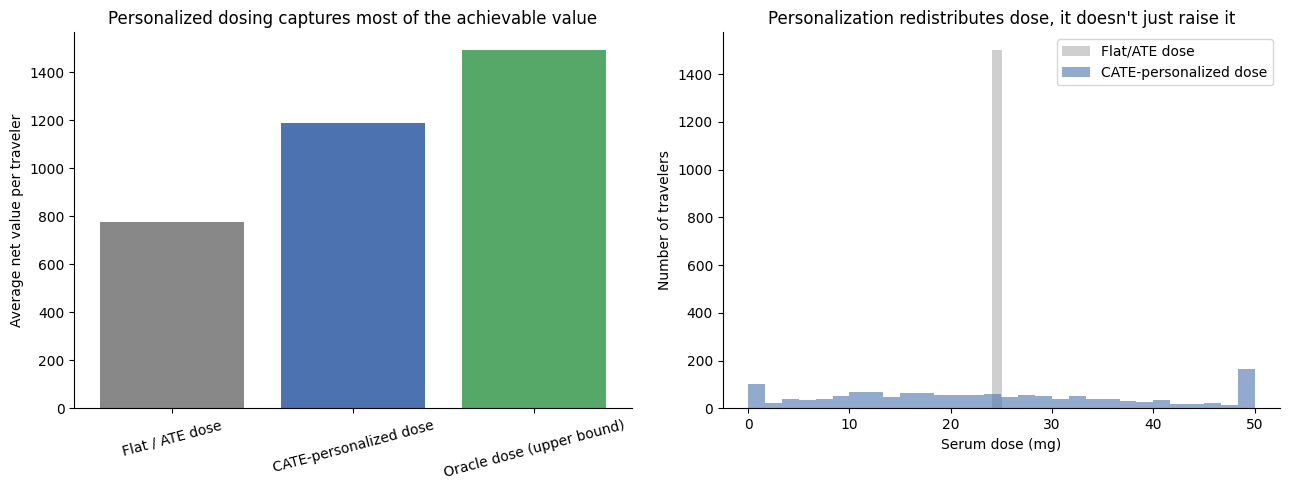

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(results["policy"], results["avg_net_value_per_traveler"],
            color=["#888888", "#4C72B0", "#55A868"])
axes[0].set_ylabel("Average net value per traveler")
axes[0].set_title("Personalized dosing captures most of the achievable value")
axes[0].tick_params(axis="x", rotation=15)

axes[1].hist(flat_dose * np.ones(len(test_pred)), bins=1, alpha=0.4,
             label="Flat/ATE dose", color="#888888")
axes[1].hist(personalized_dose, bins=30, alpha=0.6,
             label="CATE-personalized dose", color="#4C72B0")
axes[1].set_xlabel("Serum dose (mg)")
axes[1].set_ylabel("Number of travelers")
axes[1].set_title("Personalization redistributes dose, it doesn't just raise it")
axes[1].legend()

plt.tight_layout()
plt.show()



## 13. Key takeaways

1. **ATE answers "should we stock the serum?", CATE answers "who needs it, and how much?"**
   — an average mg-to-coherence conversion rate is enough for a stocking decision, but
   personalized dosing needs unit-level heterogeneity.
2. **A model that predicts the outcome `Y` (coherence) is not automatically a model of the
   treatment effect** `dY/d(mg)` — a low predicted coherence score can mean "serum would
   help a lot here" or "serum won't help this person much, something else is wrong," and
   outcome prediction alone can't tell those apart.
3. **Regression with treatment-covariate interactions is a simple, effective way to
   estimate CATE**, by differentiating the fitted model (via finite differences) instead of
   trying to regress directly on an unobservable slope target.
4. **CATE can't be validated like an ordinary ML model** (no ground-truth per-traveler
   label), so we relied on group-level tools: effect-by-quantile, cumulative effect/gain
   curves and their AUC, and target-transformation MSE.
5. **CATE only matters if it changes a decision.** We closed the loop by deriving the
   profit/value-maximizing serum dose per traveler from the CATE estimate and a simple
   cost model, and showed personalized dosing captures most of the value available versus a
   flat, one-size-fits-all policy — while also using *less* total serum on travelers who
   don't need it.

### Where to go next
- Try nonparametric CATE estimators (causal forests, meta-learners like S/T/X-learners) for
  a more flexible sensitivity model, especially if `tau` has sharp nonlinear breaks (e.g.,
  a hard threshold effect for the chronotolerant subgroup).
- Add a **hard supply constraint** — ChronoDynamics can only manufacture so much serum per
  month — and re-solve as a budget-constrained allocation problem, exactly like the
  demand-response energy-industry version of this notebook.
- Add a **safety constraint** (e.g., no traveler may receive a dose associated with more
  than a 5% predicted side-effect probability) and re-solve the optimal-dose formula subject
  to that cap.
- Replace the simulated pilot with a real (well, "real" for this universe) randomized trial
  and rerun this entire pipeline unchanged — nothing here is specific to the simulated data,
  or to this century.
